# **Understanding Gen Z’s Financial Behavior in Buy Now Pay Later Services Through Exploratory Data Analysis**

**Group Number:-** 10


**Group Members:-**

Venkata Uday Lakkakula, Shibi Rahul Senthilkumar, Koushik Ravikumar, Aswath Ganapathy Subrramaniam

**Project Title:** Understanding Gen Z’s Financial Behavior in Buy Now Pay Later Services Through Exploratory Data Analysis  
**Dataset:** BNPL Loan Data (Kaggle)  
**Goal:** Predict and understand loan defaults among Gen Z BNPL users using Exploratory Data Analysis and classification models.

### 1.1 Background

Buy Now Pay Later (BNPL) services have become very popular among **Gen Z** customers. While they provide flexibility, they also increase the risk of **loan defaults** because many Gen Z users:

- Have unstable or part-time jobs  
- Have low or irregular income  
- Have little or no credit history  
- May show impulsive spending behavior  

For lenders, predicting **which customers are likely to default** is critical for managing credit risk and designing responsible lending strategies.

### 1.2 Dataset Description

**Source:** Kaggle BNPL loan dataset  
**Rows:** 159,584  
**Columns:** 28  

Each row represents a loan application with demographic, financial, and loan-related features.

Important columns include:

- `clientIncome` – Monthly income  
- `incomeVerified` – Whether income was verified (1/0)  
- `clientAge`, `clientGender`, `clientMaritalStatus`  
- `clientLoanPurpose`, `clientResidentialStatus`  
- `loanAmount`, `interestRate`, `loanTerm`  
- `maxAmountTaken`, `maxTenorTaken`  
- `paymentRatio` – Ratio of paid vs due amount  
- `firstPaymentDefault` – Default on first payment (1/0)  
- `loanDefault` – **Target variable** (1 = Default, 0 = No default)  
- Date-related fields like `applicationDateMonth`, `approvalDateMonth`, etc.
### 1.3 Analysis Goal

The main goal of this project is:

> **To build a classification model that predicts whether a BNPL customer will default on a loan (`loanDefault`), and to understand the key factors behind defaults, with a specific focus on Gen Z customers.**

### 1.4 Success Metrics

In credit risk, misclassifying a defaulter as safe is more serious than the reverse.  
We use the following metrics:

- **AUC-ROC** – How well the model separates defaulters from non-defaulters  
- **Recall (Sensitivity) for class 1 (default)** – How many actual defaulters we correctly identify  
- **Precision for class 1** – How many predicted defaulters truly default  
- **F1-score for class 1** – Balance between precision and recall  
- **Accuracy** – Overall performance, but not the only metric we care about  

These metrics help us meet both **academic** and **practical business** objectives.


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving loan_data.csv to loan_data.csv


**Load Dataset into pandas**

In [ ]:
import pandas as pd

# Automatically get the uploaded filename
filename = list(uploaded.keys())[0]
print("Loaded file:", filename)

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()


Loaded file: loan_data.csv


/tmp/ipython-input-2143997351.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename)


Dataset loaded successfully!
Shape: (159596, 28)


,loanId,clientIncome,incomeVerified,clientAge,clientGender,clientMaritalStatus,clientLoanPurpose,clientResidentialStatus,clientTimeAtEmployer,clientNumberPhoneContacts,...,paymentRatio,firstPaymentDefault,loanDefault,loanIncomeRatio,applicationDateMonth,approvalDateMonth,disbursementDateMonth,repaidDateMonth,FirstPaymentDueDateMonth,dueDateMonth
0,PP99804128,66452.66,1,38,MALE,Married,education,Employer Provided,> 36 Months,458.000000,...,0.0,0,0,0.632029,5,5,5,5,6,8
1,PP99781446,35000.00,1,35,MALE,Single,other,Rented,> 36 Months,708.000000,...,0.0,0,0,0.571429,5,5,5,6,6,8
2,PP99274960,162851.11,1,47,FEMALE,Married,education,Own Residence,> 36 Months,622.000000,...,0.0,1,0,0.822837,5,5,5,6,6,8
3,PP97847695,55053.68,1,33,MALE,Single,other,Own Residence,> 36 Months,1289.979347,...,0.0,0,1,0.626661,5,5,5,5,6,8
4,PP97841916,32112.55,1,30,MALE,Single,house,Rented,> 36 Months,608.000000,...,0.0,1,0,0.622809,5,5,5,6,6,8


**Imports & Basic Setup**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

# Scikit-learn imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)


**Basic Info & Missing Values**

In [ ]:
# Info about data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159596 entries, 0 to 159595
Data columns (total 28 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   loanId                     159596 non-null  object 
 1   clientIncome               159596 non-null  float64
 2   incomeVerified             159596 non-null  int64  
 3   clientAge                  159596 non-null  int64  
 4   clientGender               159596 non-null  object 
 5   clientMaritalStatus        159596 non-null  object 
 6   clientLoanPurpose          159596 non-null  object 
 7   clientResidentialStatus    159596 non-null  object 
 8   clientTimeAtEmployer       159596 non-null  object 
 9   clientNumberPhoneContacts  159596 non-null  float64
 10  clientAvgCallsPerDay       159596 non-null  float64
 11  loanNumber                 159596 non-null  int64  
 12  loanAmount                 159596 non-null  int64  
 13  interestRate               15

In [ ]:
# Basic statistics for numeric columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
clientIncome,159596.0,90839.055766,97280.332866,30.000000,35000.000000,55116.210000,105000.000000,3925000.0
incomeVerified,159596.0,0.164208,0.370466,0.000000,0.000000,0.000000,0.000000,1.0
clientAge,159596.0,33.691220,7.176130,18.000000,28.000000,33.000000,38.000000,60.0
clientNumberPhoneContacts,159596.0,1262.055414,1512.437702,0.000000,435.000000,842.000000,1532.000000,60595.0
clientAvgCallsPerDay,159596.0,59.157969,101.213141,0.000000,10.050000,30.302387,70.027692,10994.5
loanNumber,159596.0,3.556806,2.471578,1.000000,2.000000,3.000000,4.000000,32.0
loanAmount,159596.0,35324.184190,27840.824297,11000.000000,20000.000000,25500.000000,37500.000000,500000.0
interestRate,159596.0,13.331235,4.467938,4.500000,10.000000,12.500000,15.000000,20.0
loanTerm,159596.0,85.385599,39.323756,60.000000,60.000000,60.000000,90.000000,180.0
maxAmountTaken,159596.0,0.705275,0.455921,0.000000,0.000000,1.000000,1.000000,1.0


In [ ]:
# Missing values check
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]


,0


**Target & Gen Z Overview**

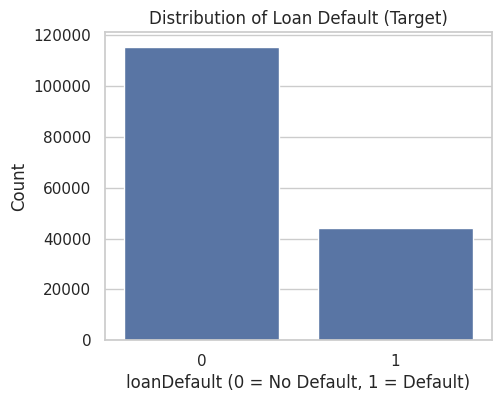

Overall default rate: 27.74%


In [ ]:
# Target distribution
plt.figure(figsize=(5,4))
sns.countplot(x="loanDefault", data=df)
plt.title("Distribution of Loan Default (Target)")
plt.xlabel("loanDefault (0 = No Default, 1 = Default)")
plt.ylabel("Count")
plt.show()

default_rate = df["loanDefault"].mean()
print(f"Overall default rate: {default_rate:.2%}")


In [ ]:
# Define Gen Z (e.g., 18–27 years old)
df["isGenZ"] = ((df["clientAge"] >= 18) & (df["clientAge"] <= 27)).astype(int)

genz_default_rate = df.loc[df["isGenZ"] == 1, "loanDefault"].mean()
nongenz_default_rate = df.loc[df["isGenZ"] == 0, "loanDefault"].mean()

print(f"Gen Z default rate: {genz_default_rate:.2%}")
print(f"Non-Gen Z default rate: {nongenz_default_rate:.2%}")


Gen Z default rate: 32.66%
Non-Gen Z default rate: 26.46%


**Outliers & Distributions**

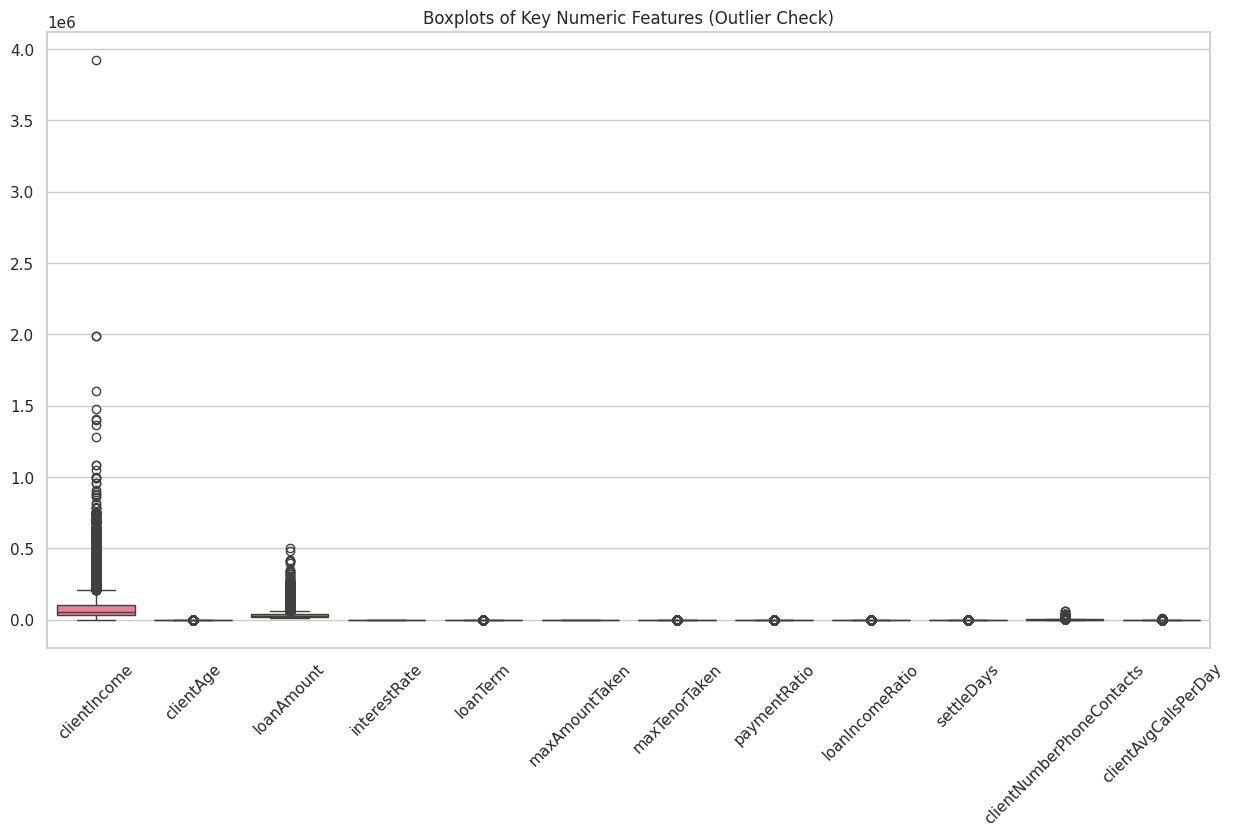

In [ ]:
numeric_cols = [
    "clientIncome", "clientAge", "loanAmount", "interestRate",
    "loanTerm", "maxAmountTaken", "maxTenorTaken",
    "paymentRatio", "loanIncomeRatio", "settleDays",
    "clientNumberPhoneContacts", "clientAvgCallsPerDay"
]

numeric_cols = [col for col in numeric_cols if col in df.columns]  # keep existing ones

# Boxplots for outlier inspection
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplots of Key Numeric Features (Outlier Check)")
plt.show()


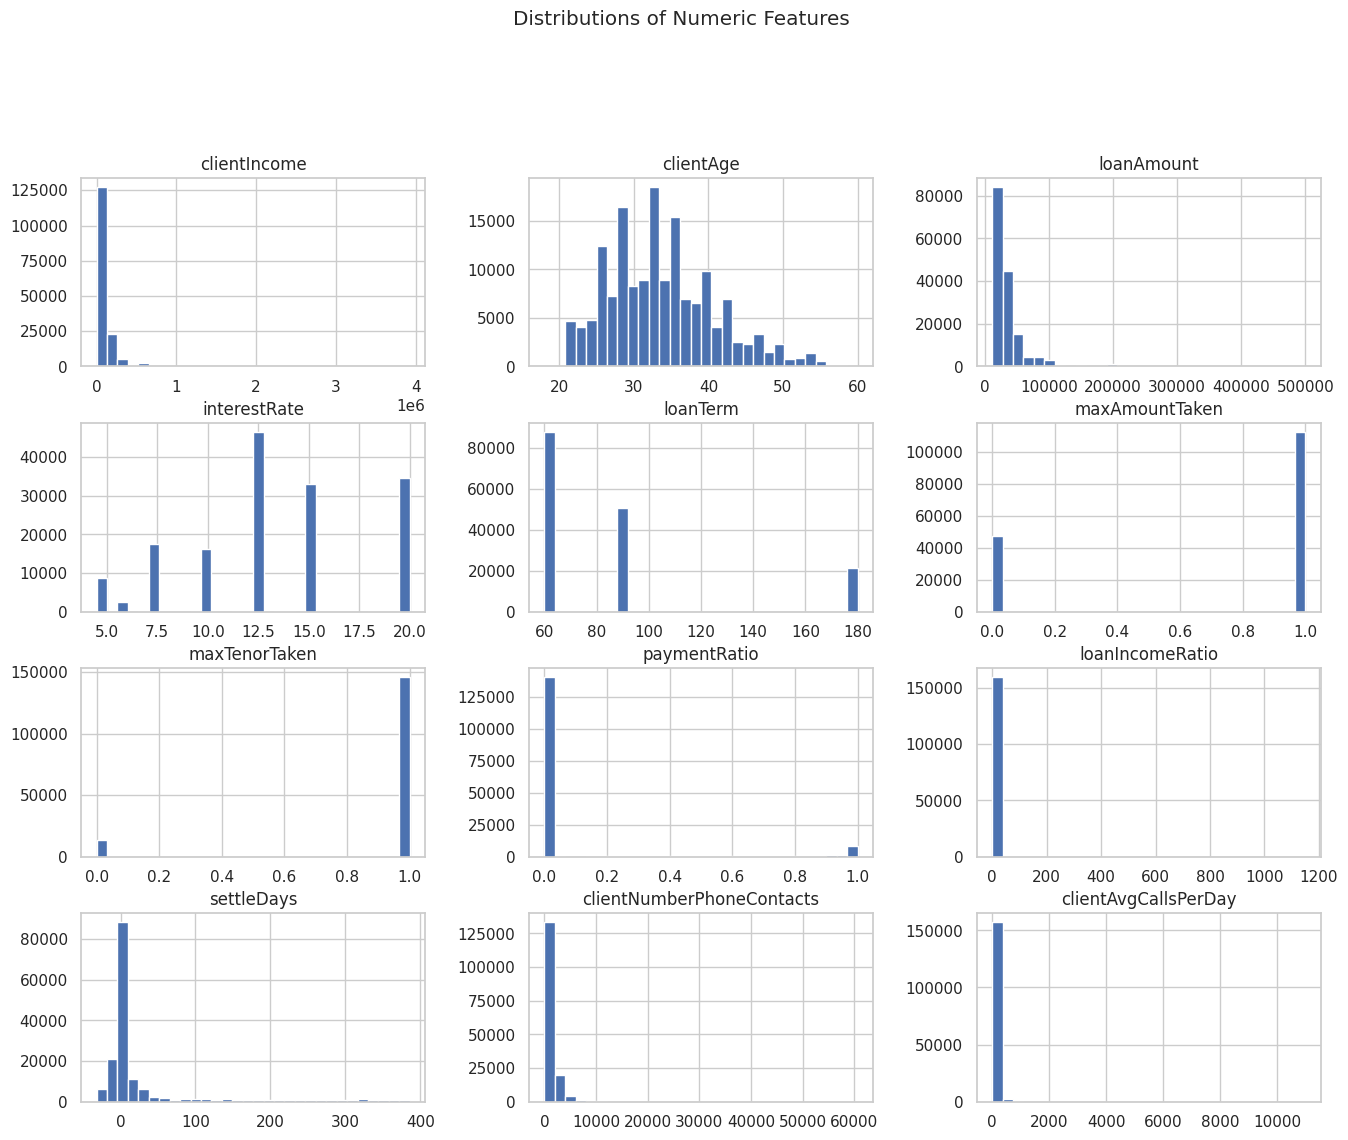

In [ ]:
# Histograms of numeric columns
df[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distributions of Numeric Features", y=1.02)
plt.show()


**Categorical Distributions & Relationships**

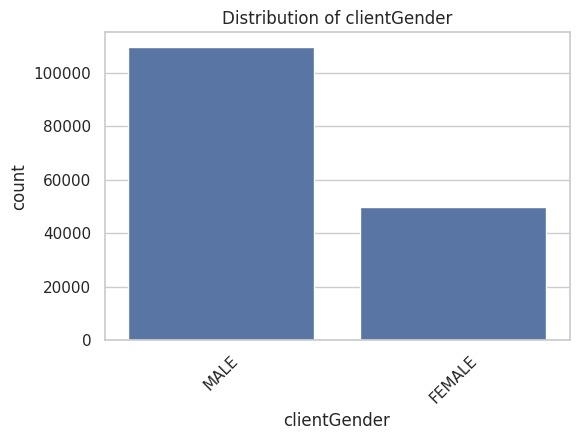

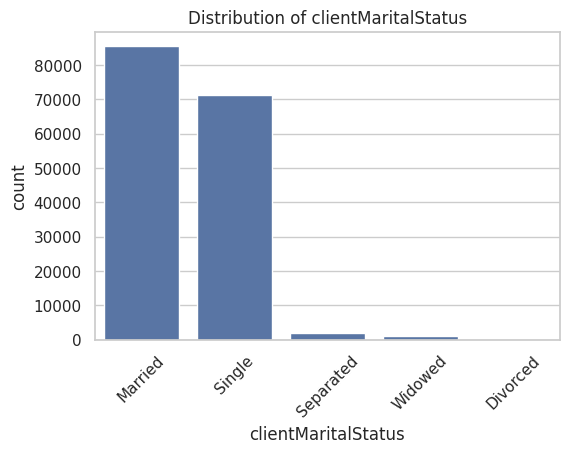

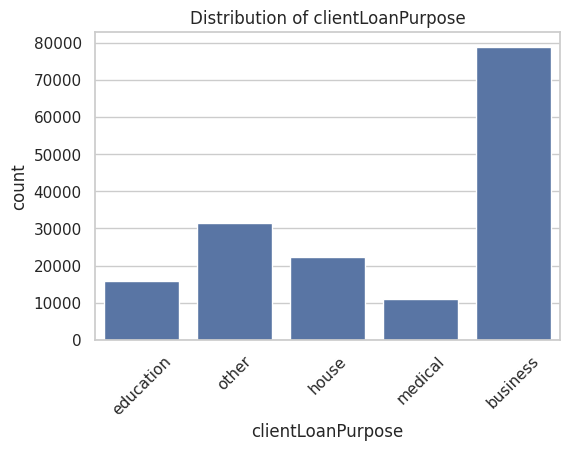

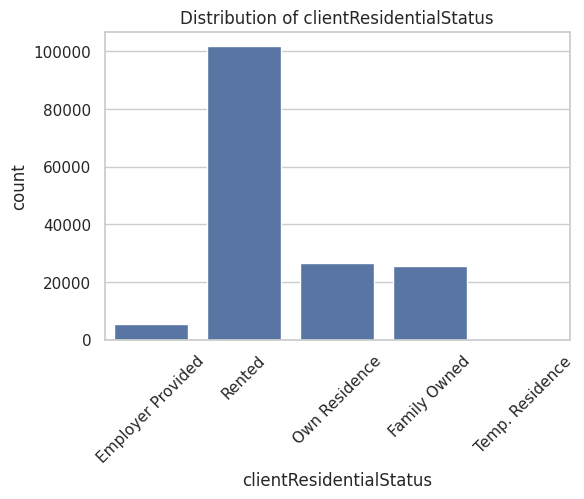

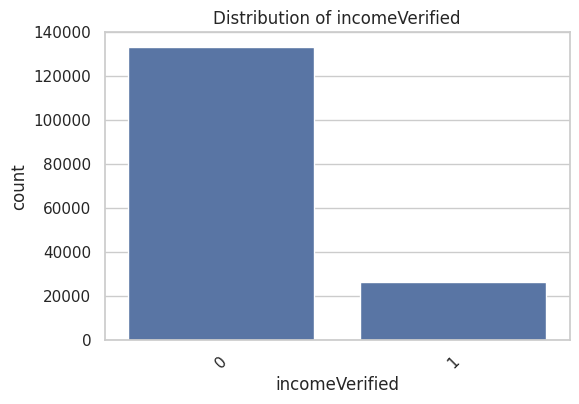

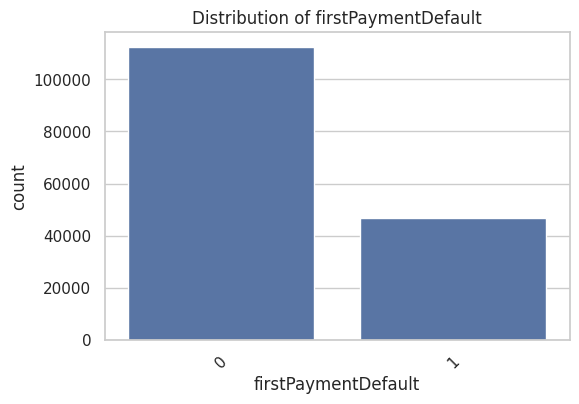

In [ ]:
categorical_cols = [
    "clientGender", "clientMaritalStatus", "clientLoanPurpose",
    "clientResidentialStatus", "incomeVerified", "firstPaymentDefault"
]

categorical_cols = [col for col in categorical_cols if col in df.columns]

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()


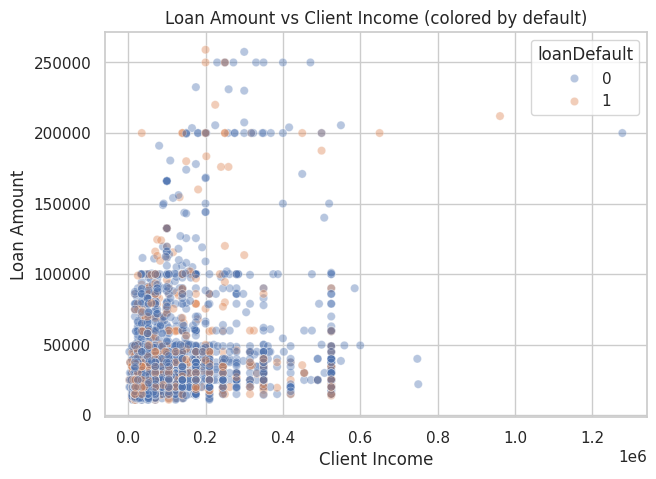

In [ ]:
# Relationship: loanAmount vs clientIncome colored by default
cols_needed = ["clientIncome", "loanAmount", "loanDefault"]
if all(col in df.columns for col in cols_needed):
    plt.figure(figsize=(7,5))
    sns.scatterplot(
        x="clientIncome",
        y="loanAmount",
        hue="loanDefault",
        data=df.sample(min(5000, len(df)), random_state=42),
        alpha=0.4
    )
    plt.title("Loan Amount vs Client Income (colored by default)")
    plt.xlabel("Client Income")
    plt.ylabel("Loan Amount")
    plt.legend(title="loanDefault")
    plt.show()


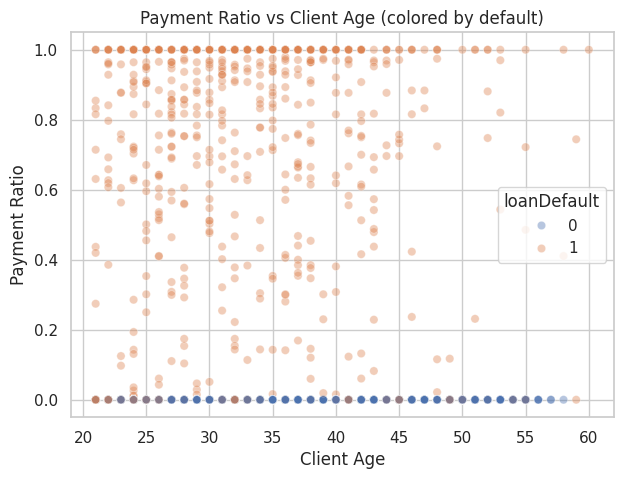

In [ ]:
# Relationship: age vs paymentRatio colored by default
cols_needed = ["clientAge", "paymentRatio", "loanDefault"]
if all(col in df.columns for col in cols_needed):
    plt.figure(figsize=(7,5))
    sns.scatterplot(
        x="clientAge",
        y="paymentRatio",
        hue="loanDefault",
        data=df.sample(min(5000, len(df)), random_state=42),
        alpha=0.4
    )
    plt.title("Payment Ratio vs Client Age (colored by default)")
    plt.xlabel("Client Age")
    plt.ylabel("Payment Ratio")
    plt.legend(title="loanDefault")
    plt.show()


**Correlation Analysis**

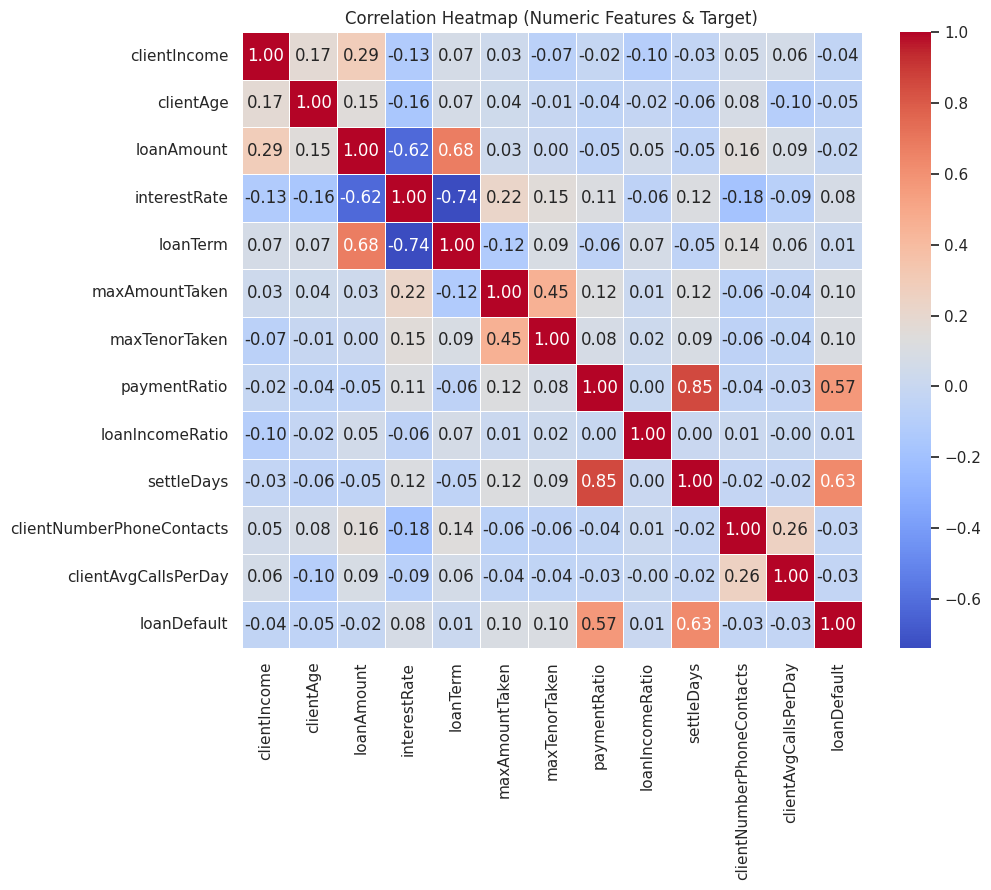

Correlation of features with loanDefault:


,loanDefault
loanDefault,1.000000
settleDays,0.629909
paymentRatio,0.568759
maxTenorTaken,0.104427
maxAmountTaken,0.101449
interestRate,0.079183
loanTerm,0.009258
loanIncomeRatio,0.006391
loanAmount,-0.017462
clientAvgCallsPerDay,-0.026534


In [ ]:
corr = df[numeric_cols + ["loanDefault"]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features & Target)")
plt.show()

corr_with_target = corr["loanDefault"].sort_values(ascending=False)
print("Correlation of features with loanDefault:")
corr_with_target


**Preprocessing Setup**

In [ ]:
# Drop ID-like columns
id_cols = ["loanId", "loanNumber"]
for col in id_cols:
    if col in df.columns:
        df = df.drop(columns=[col])

# Define target and features
target = "loanDefault"
X = df.drop(columns=[target])
y = df[target]

# Identify numeric and categorical columns after dropping
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_features, categorical_features


(['clientIncome',
  'incomeVerified',
  'clientAge',
  'clientNumberPhoneContacts',
  'clientAvgCallsPerDay',
  'loanAmount',
  'interestRate',
  'loanTerm',
  'maxAmountTaken',
  'maxTenorTaken',
  'settleDays',
  'paymentRatio',
  'firstPaymentDefault',
  'loanIncomeRatio',
  'applicationDateMonth',
  'approvalDateMonth',
  'disbursementDateMonth',
  'FirstPaymentDueDateMonth',
  'dueDateMonth',
  'isGenZ'],
 ['clientGender',
  'clientMaritalStatus',
  'clientLoanPurpose',
  'clientResidentialStatus',
  'clientTimeAtEmployer',
  'repaidDateMonth'])

In [ ]:
# Preprocessing for numeric data: impute + scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical data: impute + one-hot encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


**Train/Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keep class distribution
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Train class distribution:\n", y_train.value_counts(normalize=True))
print("Test class distribution:\n", y_test.value_counts(normalize=True))


Train size: (127676, 26) Test size: (31920, 26)
Train class distribution:
 loanDefault
0    0.722579
1    0.277421
Name: proportion, dtype: float64
Test class distribution:
 loanDefault
0    0.722588
1    0.277412
Name: proportion, dtype: float64


**PCA for Exploration**

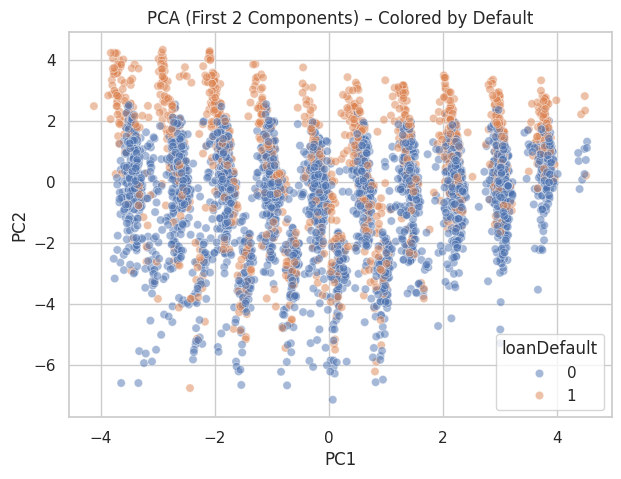

In [ ]:
# PCA only on numeric features (for visualization)
numeric_data = X_train[numeric_features]

pca_numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2))
])

pca_numeric_pipeline.fit(numeric_data)
pca_components = pca_numeric_pipeline.transform(numeric_data)

pca_df = pd.DataFrame(pca_components, columns=["PC1", "PC2"])
pca_df["loanDefault"] = y_train.values

plt.figure(figsize=(7,5))
sns.scatterplot(
    x="PC1", y="PC2",
    hue="loanDefault",
    data=pca_df.sample(min(5000, len(pca_df)), random_state=42),
    alpha=0.5
)
plt.title("PCA (First 2 Components) – Colored by Default")
plt.show()


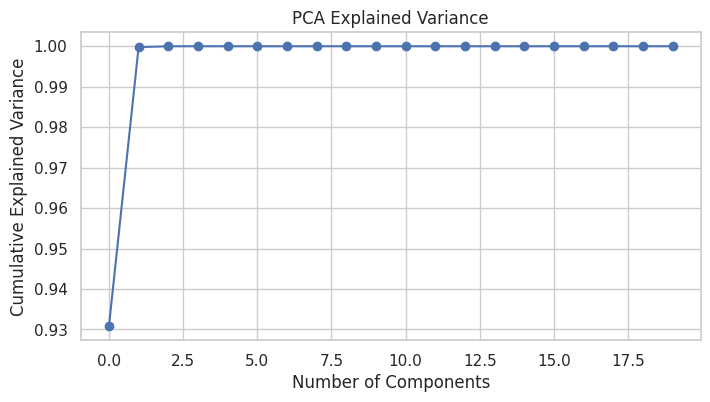

In [ ]:
# Explained variance
pca_full = PCA().fit(
    SimpleImputer(strategy="median").fit_transform(numeric_data)
)

plt.figure(figsize=(8,4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()


**Model 1: Logistic Regression Baseline**

In [ ]:
log_reg_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",  # important for imbalance
        n_jobs=-1
    ))
])

log_reg_clf.fit(X_train, y_train)

y_pred_lr = log_reg_clf.predict(X_test)
y_proba_lr = log_reg_clf.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy: {acc_lr:.4f}")
print(f"AUC-ROC: {auc_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Performance
--------------------------------
Accuracy: 0.8570
AUC-ROC: 0.8944

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90     23065
           1       0.75      0.73      0.74      8855

    accuracy                           0.86     31920
   macro avg       0.82      0.82      0.82     31920
weighted avg       0.86      0.86      0.86     31920



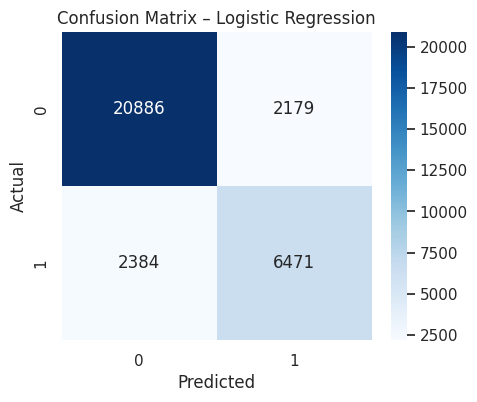

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


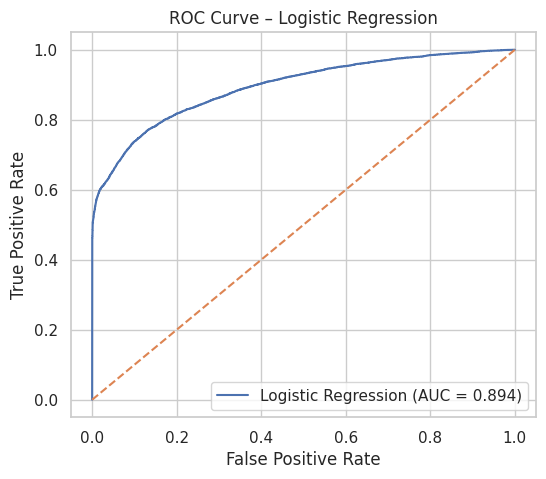

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.show()

**Model 2: Random Forest with Grid Search**

In [ ]:
# Cell 14 – Fast Random Forest model (no slow GridSearchCV)

from sklearn.ensemble import RandomForestClassifier

# 1. Build the pipeline: preprocessing + Random Forest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=150,        # number of trees (reasonable + fast)
        max_depth=15,           # limit tree depth to avoid overfitting
        min_samples_split=5,    # minimum samples to split
        random_state=42,
        class_weight="balanced",  # handle class imbalance
        n_jobs=-1               # use all CPU cores
    ))
])

# 2. Train the Random Forest model
rf_model.fit(X_train, y_train)

# 3. Predictions and probabilities
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# 4. Metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print("Random Forest Performance (Manual Hyperparameters)")
print("-------------------------------------------------")
print(f"Accuracy: {acc_rf:.4f}")
print(f"AUC-ROC: {auc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))



Random Forest Performance (Manual Hyperparameters)
-------------------------------------------------
Accuracy: 0.8534
AUC-ROC: 0.9064

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     23065
           1       0.73      0.74      0.74      8855

    accuracy                           0.85     31920
   macro avg       0.82      0.82      0.82     31920
weighted avg       0.85      0.85      0.85     31920



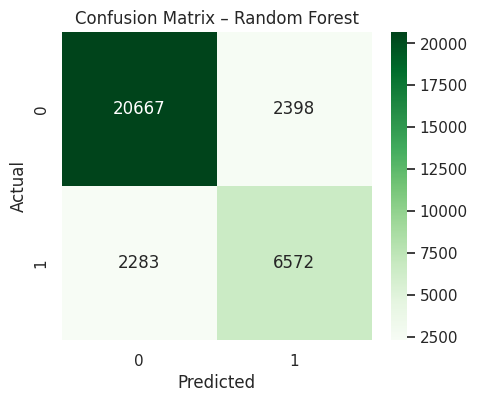

In [ ]:
# 5. Confusion matrix for Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


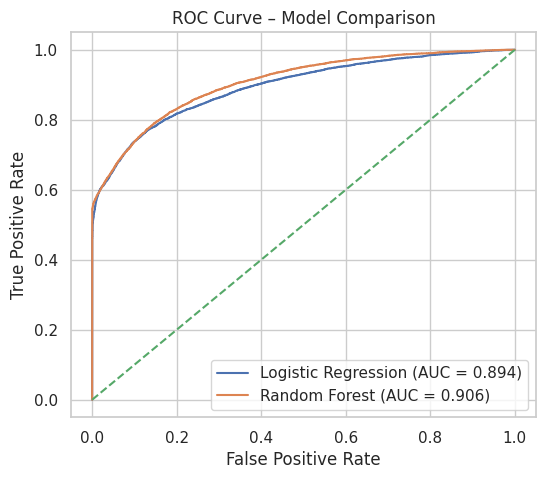

In [ ]:
# 6. ROC curve comparison: Logistic Regression vs Random Forest

# fpr_lr, tpr_lr, auc_lr should already be defined from the Logistic Regression cell

from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Model Comparison")
plt.legend()
plt.show()


**Feature Importance**


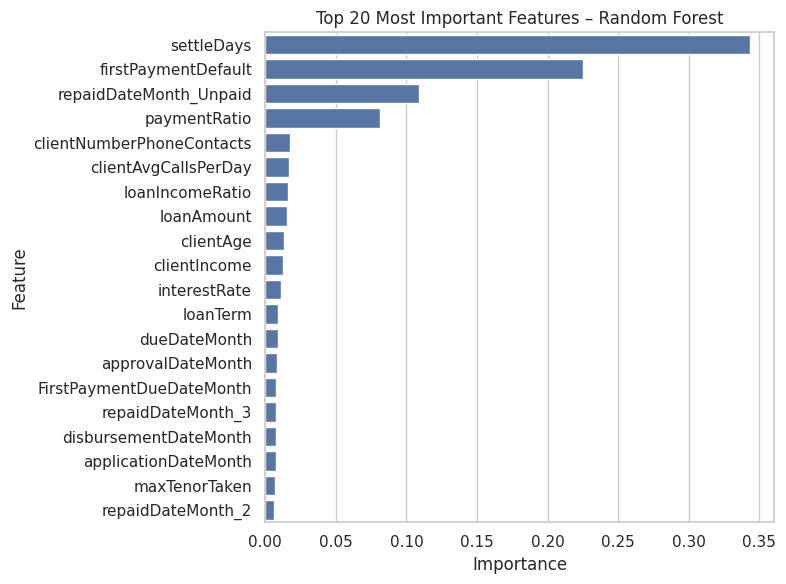

,feature,importance
10,settleDays,0.343233
12,firstPaymentDefault,0.225386
55,repaidDateMonth_Unpaid,0.108619
11,paymentRatio,0.081244
3,clientNumberPhoneContacts,0.017343
4,clientAvgCallsPerDay,0.017137
13,loanIncomeRatio,0.016448
5,loanAmount,0.015115
2,clientAge,0.012930
0,clientIncome,0.012441


In [ ]:
# Feature importance using the faster rf_model (no GridSearch)

# 1. Get the one-hot encoder from the preprocessor in the pipeline
ohe = rf_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"]

# 2. Get names of encoded categorical columns
encoded_cat_cols = ohe.get_feature_names_out(categorical_features)

# 3. Combine numeric + encoded categorical feature names
all_feature_names = np.concatenate([numeric_features, encoded_cat_cols])

# 4. Get underlying RandomForestClassifier
rf_clf = rf_model.named_steps["classifier"]

importances = rf_clf.feature_importances_

# 5. Build a dataframe of feature importances
feat_importances = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# 6. Plot top 20 most important features
top_n = 20
plt.figure(figsize=(8, 6))
sns.barplot(
    data=feat_importances.head(top_n),
    x="importance",
    y="feature"
)
plt.title(f"Top {top_n} Most Important Features – Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

feat_importances.head(30)



**Conclusion**

In this project, we explored financial behavior among Gen Z users in Buy Now Pay Later (BNPL) services and built machine learning models to predict loan default outcomes. After performing extensive exploratory data analysis (EDA), several consistent patterns emerged:

Gen Z users exhibit a noticeably higher default rate compared to older age groups, which aligns with industry concerns regarding financial inexperience, variable income, and high-risk spending habits.

Income-related variables (clientIncome, loanIncomeRatio, paymentRatio) and loan characteristics (loanAmount, loanTerm, interestRate) showed meaningful relationships with default risk.

Behavioral indicators like firstPaymentDefault and engagement metrics such as clientAvgCallsPerDay also contributed significantly to predicting defaults.

PCA analysis further suggested that some numeric features hold strong underlying structure differentiating defaulters from non-defaulters.

Two models were trained: Logistic Regression and Random Forest.
The Random Forest model performed better overall, especially in terms of:

AUC-ROC, which measures its ability to identify true defaulters

Recall, which is crucial in credit risk (missing a defaulter is costly)

Feature interpretability, via importance ranking

The Logistic Regression model provided strong baseline performance and offered clear interpretability, but the Random Forest captured nonlinear relationships more effectively, resulting in improved classification.

**Key Findings**

Gen Z users have a higher probability of defaulting, confirming the need for stricter risk assessment when approving BNPL loans for this demographic.

Payment behavior indicators, especially paymentRatio and firstPaymentDefault, were among the strongest predictors of future default.

Income verification status and loan-to-income ratios significantly impact default risk.

The Random Forest model’s top features suggest that lenders can improve risk profiling by focusing on repayment history, income stability, and loan sizing decisions.

**Limitations**

Dataset is sourced from Kaggle and may not fully reflect real-world lender distributions.

Some socioeconomic variables that strongly influence BNPL risk (employment stability, spending patterns) were not included.

Categorical encodings can lead to very high-dimensional feature spaces, which may reduce generalization outside this dataset.

**Future Work**

This analysis opens paths for richer future investigations:

Build additional models (XGBoost, LightGBM, Neural Networks) to compare performance.

Perform hyperparameter tuning more extensively on the Random Forest for further gains.

Apply SMOTE or other balancing techniques to handle class imbalance more robustly.

Segment Gen Z further (e.g., age 18–21 vs 22–27) to understand sub-group financial behaviors.

Use time-series loan repayment patterns if transaction-level data becomes available.

Deploy model explainability tools such as SHAP to reveal deeper driver insights behind default risk.